# Part 3 - Model Analysis

In this part we will consider various tools for model analysis that don't directly invovle simulations.

# Part 3.1 - Steady State Computations

Here we will describe 3 different approaches for finding model steady states.


#### Steady state finding using Homotopy Continuation

Generally, homotopy continuation is the best approach for finding model steady states. While it cannot handle some coupled reaction network/equation models, it is able to find *all* model steady states (even for systems with multiple or unstable steady states).

To find a model's steady state using Homotopy Continuation we load the Homotopy Continuation package using `import HomotopyContinuation` (`using` also works). Next, we use the `hc_steady_states`. Here we find all three steady states for the multistable Wilhelm model:

In [6]:
using Catalyst
import HomotopyContinuation

wilhelm_model = @reaction_network begin
    k1, Y --> 2X
    k2, 2X --> X + Y
    k3, X + Y --> Y
    k4, X --> 0
end

ps = [:k1 => 8.0, :k2 => 2.0, :k3 => 1.0, :k4 => 1.5]
steady_states = hc_steady_states(wilhelm_2009_model, ps)


3-element Vector{Vector{Float64}}:
 [0.4999999999999999, 1.9999999999999998]
 [4.499999999999999, 5.999999999999999]
 [0.0, 0.0]

Some models have *conservation laws*, i.e. conserved quantities that does not change throughout simulations. I.e. for the following two state model the amount of `X` is unchanged from any given initial condition:

In [7]:
two_state_model = @reaction_network begin
    (k1,k2), X1 <--> X2
end

Model ##ReactionSystem#370:
Unknowns (2): see unknowns(##ReactionSystem#370)
  X1(t)
  X2(t)
Parameters (2): see parameters(##ReactionSystem#370)
  k1
  k2

If we check its ODE equations, we note that it is the same equation twice, i.e. we cannot solve it to find a steady state:

In [8]:
ode_model(two_state_model)

Model ##ReactionSystem#370:
Equations (2):
  2 standard: see equations(##ReactionSystem#370)
Unknowns (2): see unknowns(##ReactionSystem#370)
  X1(t)
  X2(t)
Parameters (2): see parameters(##ReactionSystem#370)
  k1
  k2

However, if we have an *initial condition*, we would be able to compute the constant quantity $X1 + X2$, which would give us another equation to use to find the steady states. Homotopy handles this through the optional `u0` argument:

In [10]:
ps = [:k1 => 3.0, :k2 => 1.0]
steady_states = hc_steady_states(two_state_model, ps; u0 = [:X1 => 2.0, :X2 => 6.0])

1-element Vector{Vector{Float64}}:
 [2.0, 6.0]

Here we can see that the resulting steady state fulfils $X1 + X2 = 8.0$, just as designated by our initial condition `u0`.

#### Steady state finding using nonlinear solving

Alternatively, the steady state system of non-linear equations can be solved directly using standard methods (like e.g. Newton-Raphson). While homotopy continuation is preferred, for e.g. large systems nonlinear solving can be preferred in cases where only a single steady state is required.

Here we use an approach very similar to as for ODE simulation. However, 
1. We use the "NonlinearSolve" package.
2. We create an `NonlinearProblem`.
3. Our initial condition is not an initial condition of the system, but just a first guess from which the solve call starts. Generally, any guess of values typically works well.

In [ ]:
using NonlinearSolve
bd_model = @reaction_network begin
    (p,d), 0 <--> X
end
ps = [:p => 4.0, :d => 0.5]
u0 = [:X => 1.0]
nprob = NonlinearProblem(bd_model, u0, ps)
nsol = solve(nprob)

retcode: Success
u: 1-element Vector{Float64}:
 8.0

We can check that this value is right by simulating our model as an ODE:

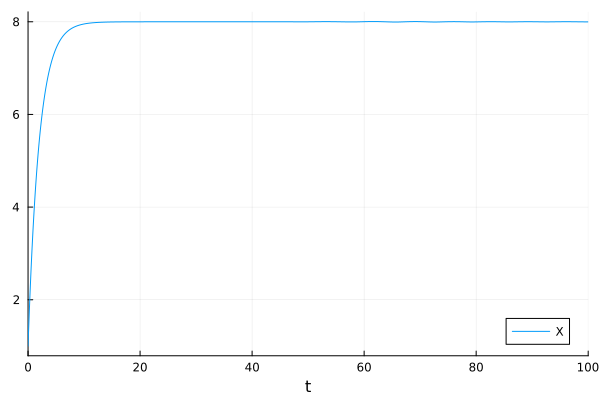

In [ ]:
using OrdinaryDiffEq, Plots
oprob = ODEProblem(bd_model, u0, 100.0, ps)
osol = solve(oprob)
plot(osol)

#### Steady state finding using ODE simulation
Alternatively, steady states can be found by simply forward ODE simulation. While this could be done manually, a easy interface is available that automatically determines when the ODE simulation has converged. here, the `SteadyStateDiffEq` package is used with the `DynamicSS(Tsit5())` solver (the inner argument is used to determine ODE solver and any special arguments for it).

In [ ]:
using SteadyStateDiffEq
solve(nprob, DynamicSS(Tsit5()))

retcode: Success
u: 1-element Vector{Float64}:
 7.999991741077752

# Part 3.2 - Bifurcation Analysis

Next we will show how Catalyst models can interface with the BifurcationKit.jl package to plot *bifurcation diagrams*. These are diagrams that show how the quantity and quality of a model's steady state changes with a specific parameter.

For this example we will use the multistable Wilhelm model again. First we declare the model

In [ ]:

wilhelm_model = @reaction_network begin
    k1, Y --> 2X
    k2, 2X --> X + Y
    k3, X + Y --> Y
    k4, X --> 0
    k5, 0 --> X
end

Model ##ReactionSystem#442:
Unknowns (2): see unknowns(##ReactionSystem#442)
  Y(t)
  X(t)
Parameters (5): see parameters(##ReactionSystem#442)
  k1
  k2
  k3
  k4
  ⋮

Next we declare: 
1. The parameter with respect to which we want to compute the bifurcation diagram. 
2. An initial parameter set at which we wish to start the computation.
3. An initial guess for a steady state at this parameter set (this works similar as for nonlinear solving, and in practise any guess should work).
4. The variable we wish to plot in the bifurcation diagram.

We then bundle all of this into a single `BifurcationProblem`.


In [25]:
using BifurcationKit
bif_par = :k1
u_guess = [:X => 5.0, :Y => 2.0]
p_start = [:k1 => 8.0, :k2 => 1.0, :k3 => 1.0, :k4 => 1.5, :k5 => 1.25]
plot_var = :X
bprob = BifurcationProblem(wilhelm_model, u_guess, p_start, bif_par; plot_var)

┌─ Bifurcation problem with uType Vector{Float64}
├─ Inplace: true
├─ Dimension: 2
├─ Symmetric: false
└─ Parameter: p1

Now we designate the parameter range over which we wish to compute the bifurcation diagram. We bundle this into a `ContinuationPar` structure (into which we can also provide other details required by the algorithm). We can then compute the diagram using the `bifurcationdiagram` function and plot it using `plot`.

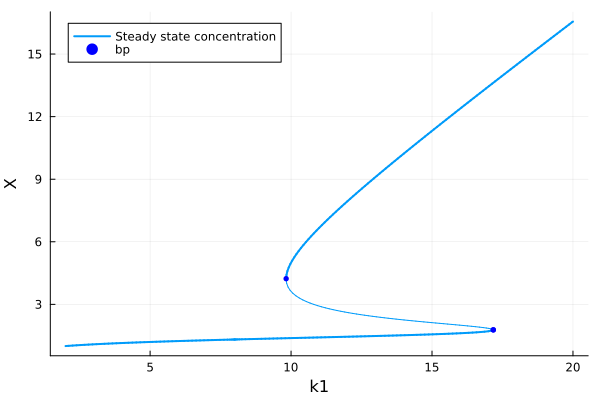

In [27]:
p_span = (2.0, 20.0)
opts_br = ContinuationPar(p_min = p_span[1], p_max = p_span[2])
bif_dia = bifurcationdiagram(bprob, PALC(), 2, opts_br; bothside = true)
plot(bif_dia; xguide = bif_par, yguide = plot_var, branchlabel = "Steady state concentration")

# Part 3.3 - Network Analysis

Finally, Catalyst provides a suite of functions for various form of *network analysis*. 


#### Querying network properties
Much of simulation-based research is carried out without consideration of a chemical reaction network's network properties. However, in the field of *chemical reaction network theory*, this is studied extensively. Here we give examples of a few properties:

In [34]:
# Declare an example model.
rn = @reaction_network begin
    (k1,k2), A + B <--> C
    k3, C --> D+E
    (k4,k5), D+E <--> F
    (k6,k7), 2A <--> B+G
    k8, B+G --> H
    k9, H --> 2A
end

Model ##ReactionSystem#465:
Unknowns (8): see unknowns(##ReactionSystem#465)
  A(t)
  B(t)
  C(t)
  D(t)
  ⋮
Parameters (9): see parameters(##ReactionSystem#465)
  k1
  k2
  k3
  k4
  ⋮

In [35]:
lcs = linkageclasses(rn)

2-element Vector{Vector{Int64}}:
 [1, 2, 3, 4]
 [5, 6, 7]

In [36]:
deficiency(rn)

0

In [37]:
isreversible(rn)

false

#### Conservation laws
We have previously mentioned that some models have conservation laws and that Catalyst uses this e.g. in the context of steady state computation. Here we will generally show how to work with this.

For the above declared model it is not immediately trivial to see what quantities are conserved. However, we can compute this using the `conservedequations` function:

In [40]:
conservedequations(rn)

3-element Vector{Equation}:
 E(t) ~ D(t) + Γ[1]
 G(t) ~ C(t) + B(t) + D(t) + F(t) + Γ[2]
 H(t) ~ -1.5C(t) - B(t) - 1.5D(t) - 0.5A(t) - 1.5F(t) + Γ[3]

Here `Γ`, describes the conserved quantities. We can see the `Γ` values directly using the `conservationlaw_constants` function:

In [41]:
conservationlaw_constants(rn)

3-element Vector{Equation}:
 Γ[1] ~ E(t) - D(t)
 Γ[2] ~ -C(t) - B(t) - D(t) + G(t) - F(t)
 Γ[3] ~ 1.5C(t) + B(t) + 1.5D(t) + 0.5A(t) + H(t) + 1.5F(t)

When we generate model equations from our reaction network model, we can , if we want, also eliminate equations associated with conservation laws:. Here we display the model equations with and without conservation law removal.

In [44]:
two_state_model = @reaction_network begin
    (k1,k2), X1 <--> X2
end
ode_model(two_state_model)

Model ##ReactionSystem#492:
Equations (2):
  2 standard: see equations(##ReactionSystem#492)
Unknowns (2): see unknowns(##ReactionSystem#492)
  X1(t)
  X2(t)
Parameters (2): see parameters(##ReactionSystem#492)
  k1
  k2

In [45]:
ode_model(two_state_model; remove_conserved = true)

Model ##ReactionSystem#492:
Equations (1):
  1 standard: see equations(##ReactionSystem#492)
Unknowns (1): see unknowns(##ReactionSystem#492)
  X1(t)
Parameters (3): see parameters(##ReactionSystem#492)
  k1
  k2
  Γ [defaults to missing]
Observed (1): see observed(##ReactionSystem#492)

Here we just see the equations, but we can use the same when we simulate an ODE model using the same option

In [47]:
u0 = [:X1 => 3.0, :X2 => 1.0]
ps = [:k1 => 4.0, :k2 => 2.0]
oprob = ODEProblem(two_state_model, u0, 2.0, ps; remove_conserved = true)
osol = solve(oprob)
plot(osol)

UndefVarError: UndefVarError: `solve` not defined in `Main`
Hint: It looks like two or more modules export different bindings with this name, resulting in ambiguity. Try explicitly importing it from a particular module, or qualifying the name with the module it should come from.
Hint: a global variable of this name also exists in HomotopyContinuation.
Hint: a global variable of this name also exists in CommonSolve.
    - Also exported by SciMLBase.
    - Also exported by BracketingNonlinearSolve.
    - Also exported by DiffEqBase.
    - Also exported by JumpProcesses.
    - Also exported by LinearSolve.
    - Also exported by NonlinearSolveFirstOrder.
    - Also exported by OrdinaryDiffEqCore (loaded but not imported in Main).
    - Also exported by ImplicitDiscreteSolve (loaded but not imported in Main).
    - Also exported by ModelingToolkitBase.
    - Also exported by Catalyst.
    - Also exported by SimpleNonlinearSolve.
    - Also exported by NonlinearSolveQuasiNewton.
    - Also 

Above, the value of $Γ$ (the conservation law parameter) is computed automatically from $X1$ and $X2$. However, we can also provide it directly instead of providing a value of $X2$:

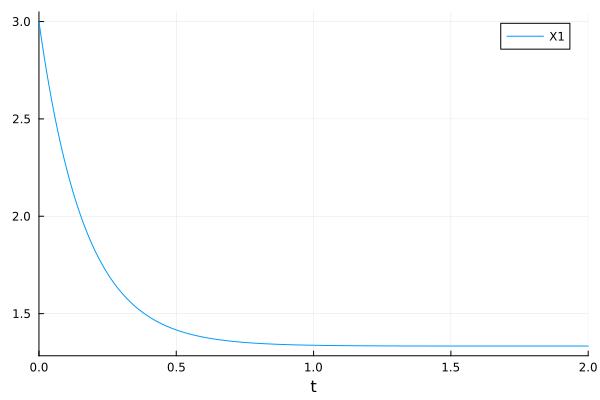

In [48]:
u0 = [:X1 => 3.0]
ps = [:k1 => 4.0, :k2 => 2.0, :Γ => [4.0]] # Γ is a vector parameter, so its values are provided in a vector.
oprob = ODEProblem(two_state_model, u0, 2.0, ps; remove_conserved = true)
osol = OrdinaryDiffEq.solve(oprob)
plot(osol)